# Plan de travail utiliser

* 1. Charger la base de données METABRIC (Breast Cancer METABRIC.csv)
    * Importer le dataset, vérifier son format et préparer l’environnement d’analyse.

* 2. Nettoyer la base de données => voir utils/train_surv_model.py
    * Gestion des valeurs manquantes, Harmonisation des types de variables, Encodage des variables catégorielles et Vérification des doublons et anomalies

* 3. Explorer le dataset (EDA) => voir brast_predict_analyse.py
    * Statistiques descriptives, Analyse des distributions, Corrélations, Sélection des variables pertinentes pour la survie et Vérification des variables cliniques importantes (âge, statut ER, grade, etc.)

* 4. Séparer les données en train/test et définir features + labels => voir utils/train_surv_model.py
    * Construction de la structure de survie : (time, event) et  Séparation X_train / X_test et y_train / y_test

* 5. Définir les pipelines d’entraînement => voir utils/train_surv_model.py
    * Pipeline CoxPHSurvivalAnalysis, Pipeline RandomSurvivalForest, Pipeline GradientBoostingSurvivalAnalysis et préprocessing intégré (scaler, imputer, encoder)

* 6. Optimisation des modèles
    * Application d’une GridSearchCV pour rechercher les meilleurs hyperparamètres, Validation croisée (k-fold) pour évaluer la stabilité des performances et Comparaison des modèles d’une même famille (Cox vs RSF vs GBSA)

* 7. Analyse des performances
    * C-index sur train/test, Courbes de survie prédictives,  Importance des variables (selon le modèle)

* 8. Exploitation des prédictions pour la stratification du risque
    * Création de groupes de risque (bas / haut risque) à partir des prédictions, Tracé des courbes de Kaplan-Meier pour chaque groupe, Log-rank test pour vérifier la séparation statistique, Visualisation des courbes de survie individuelles et moyennes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sklearn.inspection import permutation_importance
from utils import SurvivalModelWrapper, km_by_group
from sksurv.metrics import brier_score, integrated_brier_score


## Lecture du dataset et mise en forme

In [2]:
df_raw = pd.read_csv('projet.csv', 
    na_values="?",        # Treat '?' as missing values (NaN).
    comment="\t",         # Lines starting with tab ("\t") are comments. Ignore.
    sep=",",              # Use comma as a separator.
    skipinitialspace=True,# Skip initial spaces in the data.
)

In [3]:
# Après analyses ses donnée ne sont pas itiles pour la prédiction car peuvent causer des bias
exculde_features = ["patient_id", "patient's_vital_status", "cancer_type_detailed", "cancer_type", "oncotree_code", 
                    "3-gene_classifier_subtype", "primary_tumor_laterality", "sex", "hormone_therapy", "mutation_count"]


# hormone_therapy ou er_status_measured_by_ihc
# "her2_status_measured_by_snp6",  "radio_therapy"
categorical_features = ["chemotherapy", "pam50_+_claudin-low_subtype",  "pr_status", "er_status_measured_by_ihc", 
                    "inferred_menopausal_state", "integrative_cluster", "type_of_breast_surgery"]

ordinal_features = {"neoplasm_histologic_grade": [1., 2., 3.], 
                    "tumor_stage": [0., 1., 2., 3., 4. ], 
                    "cellularity": ['Low','Moderate','High']
                    }

numerical_features = ["nottingham_prognostic_index", "lymph_nodes_examined_positive", "age_at_diagnosis"]

## Implementaion des Models

In [4]:
rsf_model = RandomSurvivalForest(
    n_estimators=400,
    min_samples_split=500,
    min_samples_leaf=250,
    random_state=42
)

gsf_model = GradientBoostingSurvivalAnalysis(
    n_estimators= 200,
    min_samples_split = 400,
    min_samples_leaf = 250,
)

cox_model = CoxPHSurvivalAnalysis(
    alpha=1, 
    ties="efron"
)

In [5]:
# Créer ton wrapper
cox = SurvivalModelWrapper(
    data=df_raw,
    model=cox_model,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

gsf = SurvivalModelWrapper(
    data=df_raw,
    model=gsf_model,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

rsf = SurvivalModelWrapper(
    data=df_raw,
    model=rsf_model,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

In [6]:
# Cross validation pour tuning des hyperparamètres
param_grid = {
    "survival_model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
    "survival_model__ties": ["breslow", "efron"]
}

cox.tune_parameters(param_grid, event_col="event", duration_col="duration", cv=5)

Meilleurs paramètres : {'survival_model__alpha': 1.0, 'survival_model__ties': 'efron'}


{'survival_model__alpha': 1.0, 'survival_model__ties': 'efron'}

In [7]:
cox.get_pipeline()

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['chemotherapy',
                                                   'pam50_+_claudin-low_subtype',
                                                   'pr_status',
                                                   'er_status_measured_by_ihc',
                                                   'inferred_menopausal_state',
                                                   'integrative_cluster',
                                                   'ty...
                                                                                               4.0],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High']]))]),
                                                  ['neoplasm_histologic_grade',
                                                   'tumor_stage',
                                                   'cellularity']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['nottingham_prognostic_index',
                                                   'lymph_nodes_examined_positive',
                                                   'age_at_diagnosis'])])),
                ('survival_model',
                 CoxPHSurvivalAnalysis(alpha=1.0, ties='efron'))])

## Evaluation du model

In [8]:
# 6. Entraîner
X_test, y_test_surv, y_train_surv = rsf.fit()
X_test, y_test_surv, y_train_surv = gsf.fit()
X_test, y_test_surv, y_train_surv = cox.fit()


# 7. Afficher le C-index
print("C-index_cox:", cox.c_index_)
print("C-index_gsf:", gsf.c_index_)
print("C-index_rsf:", rsf.c_index_)

C-index_cox: 0.6551399159054662
C-index_gsf: 0.6428157169783965
C-index_rsf: 0.6770334928229665


In [9]:
cv_scores = cox.evaluate_with_cv(cv=5)

--- Résultats de la Validation Croisée (5 folds) ---
C-index moyen : 0.6741
Écart-type     : 0.0407
Scores par fold : [0.75296345 0.64757978 0.6465676  0.64989239 0.67334205]


## Les variables les plus inportantes du model

In [10]:
# Attention : cela peut être lent sur de gros datasets
result_0 = permutation_importance(
    cox.get_pipeline(), # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42)

result_1 = permutation_importance(
    rsf.get_pipeline(), # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

result_2 = permutation_importance(
    gsf.get_pipeline(), # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )


In [11]:
# Affichage des résultats globaux
perm_df = pd.DataFrame({
    "feature": cox.get_feature()[0],
    "importance_cox": result_0.importances_mean,
    "importance_rsf": result_1.importances_mean,
    "importance_gsf": result_2.importances_mean
}).sort_values(by="importance_cox", ascending=False)
perm_df.head(10)

,feature,importance_cox,importance_rsf,importance_gsf
9,age_at_diagnosis,0.071408,0.044371,0.039445
4,inferred_menopausal_state,0.028802,-0.001928,0.000000
0,chemotherapy,0.016043,-0.000130,0.002994
7,nottingham_prognostic_index,0.012585,0.042022,0.037317
5,integrative_cluster,0.011121,0.000000,0.000000
6,type_of_breast_surgery,0.009888,0.019316,0.006699
8,lymph_nodes_examined_positive,0.007677,0.018736,0.015880
3,er_status_measured_by_ihc,0.007083,0.000149,0.000000
2,pr_status,0.007003,0.012429,0.006488
11,tumor_stage,0.005981,0.007173,0.002911


## Prediction et appplication clinique


| Ce que tu veux obtenir | Méthode dans `CoxPHSurvivalAnalysis` | Commentaire |
|------------------------|-------------------------------------|-------------|
| Score linéaire $\beta X$ | `model.predict(X)` | C’est le *risk score* non exponentié |
| Risque relatif $\exp(\beta X)$ | `model.predict(X, return_array=True)` puis `np.exp(...)` | combien de fois le patient est plus à risque qu’un patient de référence (tourjours positif) |
| Fonction de survie individuelle | `model.predict_survival_function(X)` | Renvoie une liste de courbes de survie |
| Risque cumulé | `model.predict_cumulative_hazard_function(X)` | Renvoie une liste de fonctions de risque cumulé  |


In [12]:
df_test = pd.concat([X_test.reset_index(drop=True), 
                    pd.DataFrame(y_test_surv).reset_index(drop=True)], 
                    axis=1
)

In [13]:
pipline = cox.get_pipeline()
# Score linéaire
linear_score = pipline.predict(X_test)

# Risque relatif
partial_hazard = np.exp(linear_score)

# Courbes de survie
surv_funcs = pipline.predict_survival_function(X_test)

# Risque cumulé
cumhaz_funcs = pipline.predict_cumulative_hazard_function(X_test)


===== Kaplan-Meier : risk_group =====


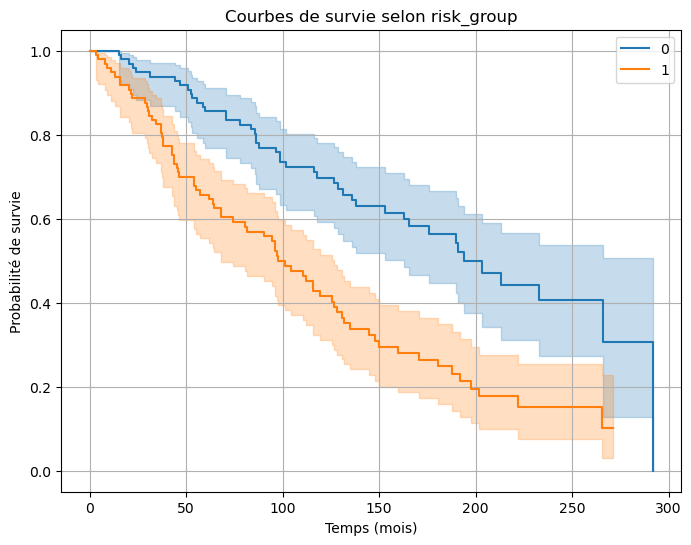


Log-rank test :
Log-rank test p-value : <lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          21.26 <0.005     17.93
Le modèle discrimine bien les risques


In [14]:
#  Stratifier les patients en groupes de risque
risk_group = (partial_hazard > np.median(partial_hazard))
df_test["risk_group"] = (partial_hazard > np.median(partial_hazard)).astype(int)

# Comparer la survie entre groupes:
# courbe de Kaplan‑Meier pour chaque groupe
# un log‑rank test pour vérifier si les courbes sont significativement différentes

km_by_group(df_test, "duration", "event", group_col="risk_group")
# Résultat :
# Deux courbes KM, une pour les patients à faible risque, une pour les patients à haut risque.
# Si les courbes sont bien séparées → ton modèle a une bonne valeur clinique.

3. Interprétation clinique
✔️ Haut risque
* survie plus faible
* événement plus précoce
* nécessite surveillance renforcée ou traitement agressif

✔️ Bas risque
* survie meilleure
* suivi standard

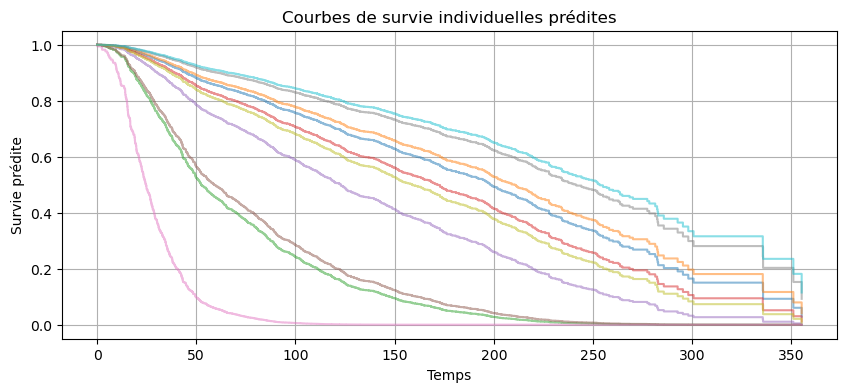

In [15]:
plt.figure(figsize=(10, 4))

for i, f in enumerate(surv_funcs[:10]):  # tracer 10 patients
    plt.step(f.x, f.y, where="post", alpha=0.5)

plt.title("Courbes de survie individuelles prédites")
plt.xlabel("Temps")
plt.ylabel("Survie prédite")
plt.grid(True)
plt.show()

In [16]:
# Assuming X_test and y_test_surv are defined from previous cells
# Define evaluation times (adjust based on your data's time range)

    

def test_brier_scores(times, preds):
    """
    Test function to compute Brier scores for all models and assert basic properties.
    """
    
    time, brier_scores = brier_score(y_train_surv, y_test_surv, preds, times)
     
    # Plot the curve
    plt.figure(figsize=(8, 6))
    plt.plot(time, brier_scores, label='Cox model Brier Score')
    plt.xlabel('Durrée en mois')
    plt.ylabel('Brier Score')
    plt.title(f'Brier Score Curve pour Cox model')
    plt.ylim(0, 1)  # Brier score ranges from 0 to 1
    plt.grid(True)
    plt.legend()
    plt.show()

    integrated_score = integrated_brier_score(y_train_surv, y_test_surv, preds, times)
    
    print("All Brier score tests passed.")
    return brier_scores, integrated_score

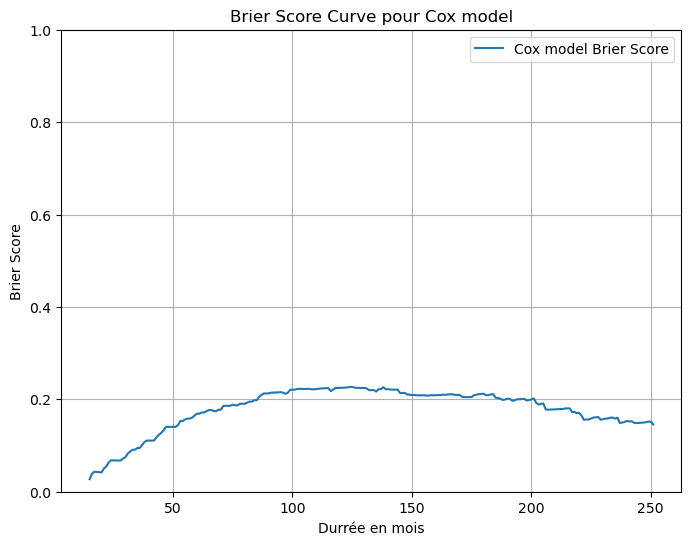

All Brier score tests passed.


In [17]:
lower, upper = np.percentile(y_test_surv["duration"], [5, 95])
times = np.arange(lower, upper)  
preds = np.array([[f(t) for t in times] for f in surv_funcs])

# Run the test
test_results, integrated_score = test_brier_scores(times, preds)

In [18]:
integrated_score

0.17891175842497367